# Heart Disease Prediction

This project predicts whether a patient has heart disease using machine learning models.
We compare Logistic Regression, Decision Tree, and Random Forest and choose the best model.

**Dataset:** Cleveland Heart Disease Dataset (Kaggle)  
**Type:** Binary Classification (0 = No Disease, 1 = Disease)

## Step 1 - Import Libraries

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc

import warnings
warnings.filterwarnings('ignore')

## Step 2 - Load Datasets

In [2]:
df = pd.read_csv('Heart_disease_cleveland_new.csv')
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,0,145,233,1,2,150,0,2.3,2,0,2,0
1,67,1,3,160,286,0,2,108,1,1.5,1,3,1,1
2,67,1,3,120,229,0,2,129,1,2.6,1,2,3,1
3,37,1,2,130,250,0,0,187,0,3.5,2,0,1,0
4,41,0,1,130,204,0,2,172,0,1.4,0,0,1,0


## Step 3 - Understand the Datasets

In [3]:
column_info = {
    'age'     : 'Age of the patient in years',
    'sex'     : '1 = Male, 0 = Female',
    'cp'      : 'Chest pain type (0-3)',
    'trestbps': 'Resting blood pressure (mm Hg)',
    'chol'    : 'Serum cholesterol (mg/dl)',
    'fbs'     : 'Fasting blood sugar > 120 mg/dl (1=True)',
    'restecg' : 'Resting ECG results (0-2)',
    'thalach' : 'Maximum heart rate achieved',
    'exang'   : 'Exercise induced angina (1=Yes)',
    'oldpeak' : 'ST depression induced by exercise',
    'slope'   : 'Slope of peak exercise ST segment',
    'ca'      : 'Number of major vessels (0-3)',
    'thal'    : 'Thalassemia type (0-3)',
    'target'  : '1 = Heart Disease, 0 = No Heart Disease'
}

## Step 4 - Basic Exploration

In [4]:
df.head(7)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,0,145,233,1,2,150,0,2.3,2,0,2,0
1,67,1,3,160,286,0,2,108,1,1.5,1,3,1,1
2,67,1,3,120,229,0,2,129,1,2.6,1,2,3,1
3,37,1,2,130,250,0,0,187,0,3.5,2,0,1,0
4,41,0,1,130,204,0,2,172,0,1.4,0,0,1,0
5,56,1,1,120,236,0,0,178,0,0.8,0,0,1,0
6,62,0,3,140,268,0,2,160,0,3.6,2,2,1,1


In [5]:
df.shape

(303, 14)

In [6]:
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='str')

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [8]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.438944,0.679868,2.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,0.600660,0.663366,1.831683,0.458746
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.934375,0.956705,0.499120
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,48.000000,0.000000,2.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
50%,56.000000,1.000000,2.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,1.000000,0.000000
75%,61.000000,1.000000,3.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,1.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,3.000000,3.000000,1.000000


## Step - 5 Checking Missing Values and Duplicates

In [9]:
# Check for missing values
missing = df.isnull().sum()
print(missing)
print(f'\nTotal missing values: {missing.sum()}')

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Total missing values: 0


In [10]:
# Check duplicate rows
print(f'Duplicate rows: {df.duplicated().sum()}')

Duplicate rows: 0


## Step - 6 Visualization

target
0    164
1    139
Name: count, dtype: int64


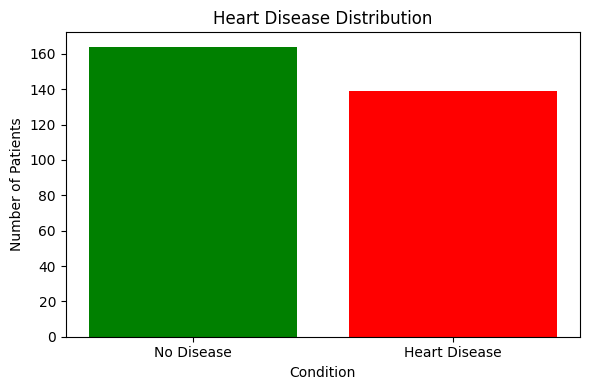

In [11]:
# Target variable distribution
target_counts = df['target'].value_counts()
print(target_counts)
plt.figure(figsize=(6, 4))
plt.bar(['No Disease', 'Heart Disease'], target_counts.values, color=['green', 'red'])
plt.title('Heart Disease Distribution')
plt.xlabel('Condition')
plt.ylabel('Number of Patients')
plt.tight_layout()
plt.show()

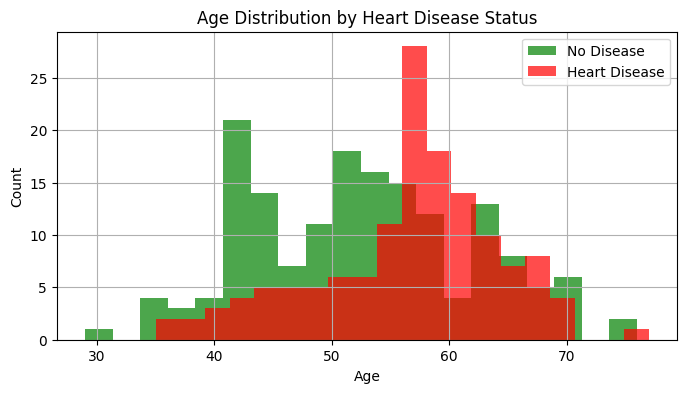

In [12]:
# Age distribution by disease
plt.figure(figsize=(8, 4))
df[df['target'] == 0]['age'].hist(bins=20, alpha=0.7, color='green', label='No Disease')
df[df['target'] == 1]['age'].hist(bins=20, alpha=0.7, color='red', label='Heart Disease')
plt.title('Age Distribution by Heart Disease Status')
plt.xlabel('Age')
plt.ylabel('Count')
plt.legend()
plt.show()

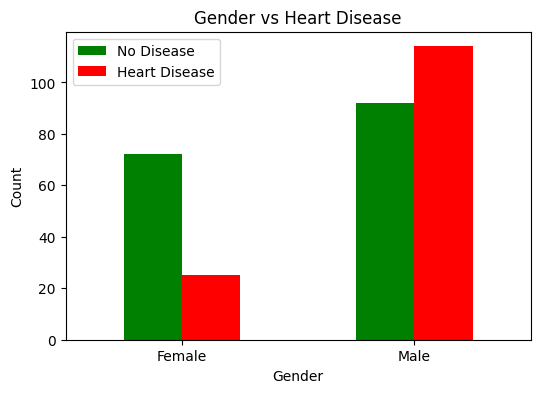

In [13]:
# Gender vs Heart Disease
gender_disease = df.groupby(['sex', 'target']).size().unstack()
gender_disease.index = ['Female', 'Male']
gender_disease.columns = ['No Disease', 'Heart Disease']

plt.figure(figsize=(6, 4))
gender_disease.plot(kind='bar', color=['green', 'red'], ax=plt.gca())
plt.title('Gender vs Heart Disease')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend()
plt.show()

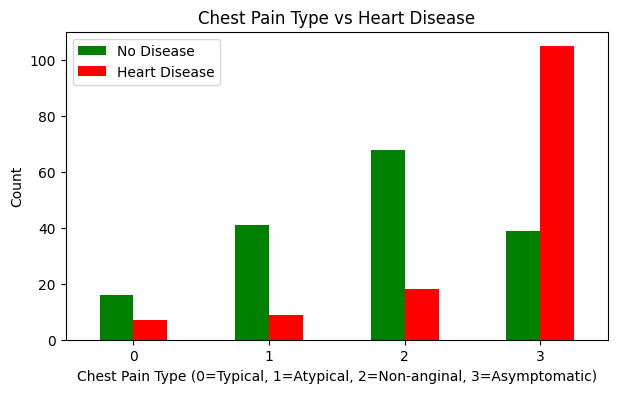

In [14]:
# Chest pain type vs Heart Disease
cp_disease = df.groupby(['cp', 'target']).size().unstack()
cp_disease.columns = ['No Disease', 'Heart Disease']

plt.figure(figsize=(7, 4))
cp_disease.plot(kind='bar', color=['green', 'red'], ax=plt.gca())
plt.title('Chest Pain Type vs Heart Disease')
plt.xlabel('Chest Pain Type (0=Typical, 1=Atypical, 2=Non-anginal, 3=Asymptomatic)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend()
plt.show()

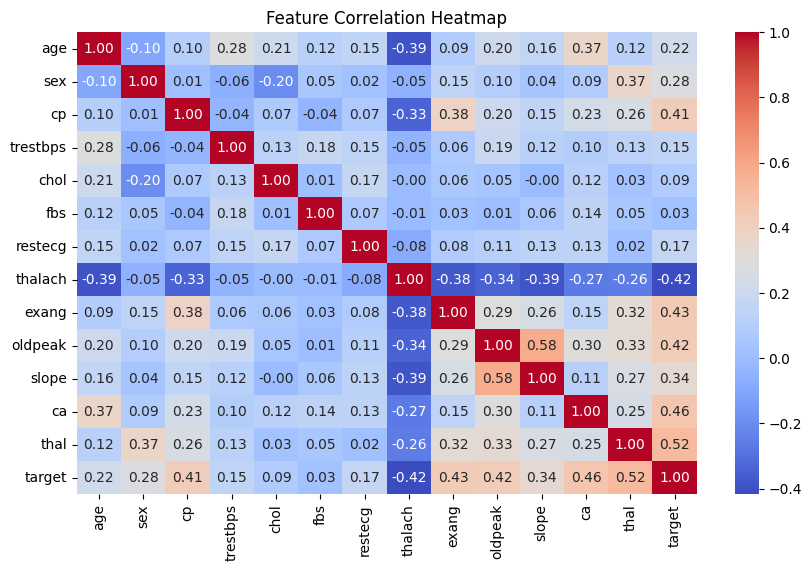

Top features correlated with target:
target      1.000000
thal        0.515894
ca          0.460033
exang       0.431894
oldpeak     0.424510
cp          0.414446
slope       0.339213
sex         0.276816
age         0.223120
restecg     0.169202
trestbps    0.150825
chol        0.085164
fbs         0.025264
thalach    -0.417167
Name: target, dtype: float64


In [15]:
# Correlation Heatmap
plt.figure(figsize=(10, 6))
corr = df.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

print('Top features correlated with target:')
print(corr['target'].sort_values(ascending=False))

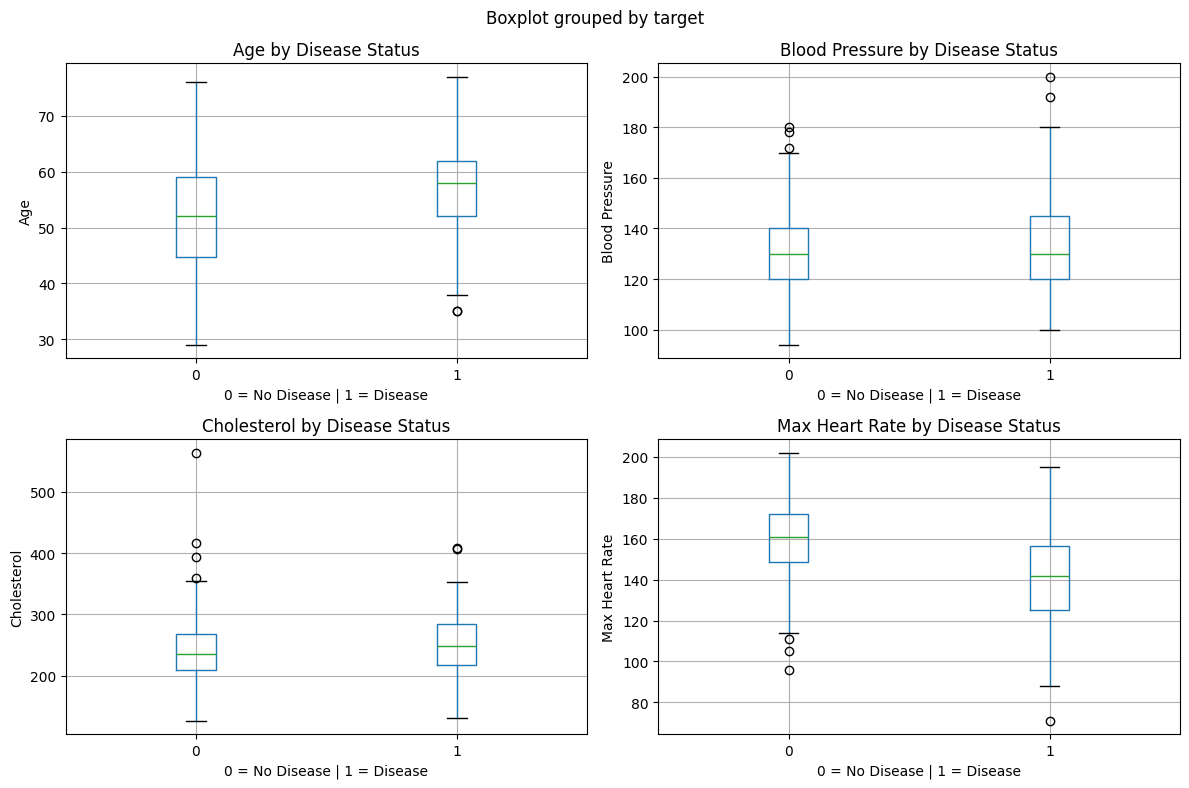

In [16]:
# Boxplots for key numerical features
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
features = ['age', 'trestbps', 'chol', 'thalach']
titles = ['Age', 'Blood Pressure', 'Cholesterol', 'Max Heart Rate']

for ax, feature, title in zip(axes.flatten(), features, titles):
    df.boxplot(column=feature, by='target', ax=ax)
    ax.set_title(f'{title} by Disease Status')
    ax.set_xlabel('0 = No Disease | 1 = Disease')
    ax.set_ylabel(title)
plt.tight_layout()
plt.show()

## Step 7 - Data Preprocessing

In [17]:
# Separate features and target
X = df.drop('target', axis=1)
y = df['target']

print(f'Features shape: {X.shape}')
print(f'Target shape: {y.shape}')
print(f'\nFeatures used: {list(X.columns)}')

Features shape: (303, 13)
Target shape: (303,)

Features used: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']


In [18]:
# Split into train and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f'Training set: {X_train.shape[0]} samples')
print(f'Testing set : {X_test.shape[0]} samples')

Training set: 242 samples
Testing set : 61 samples


In [19]:
# Scale the features 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

## Step 8 - Build and Train ML Models

In [20]:
# Model 1 — Logistic Regression
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_scaled, y_train)
lr_pred = lr_model.predict(X_test_scaled)
lr_acc  = accuracy_score(y_test, lr_pred)

print(f'Logistic Regression Accuracy: {lr_acc*100:.2f}%')

Logistic Regression Accuracy: 86.89%


In [21]:
# Model 2 — Decision Tree
dt_model = DecisionTreeClassifier(random_state=42, max_depth=5)
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)
dt_acc  = accuracy_score(y_test, dt_pred)

print(f'Decision Tree Accuracy: {dt_acc*100:.2f}%')

Decision Tree Accuracy: 78.69%


In [22]:
# Model 3 — Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_acc  = accuracy_score(y_test, rf_pred)

print(f'Random Forest Accuracy: {rf_acc*100:.2f}%')

Random Forest Accuracy: 88.52%


## Step - 9 Compare all 3 models

In [23]:
# Model comparison table
results = pd.DataFrame({
    'Model'   : ['Logistic Regression', 'Decision Tree', 'Random Forest'],
    'Accuracy': [lr_acc*100, dt_acc*100, rf_acc*100]
})
results['Accuracy'] = results['Accuracy'].round(2)
results = results.sort_values('Accuracy', ascending=False).reset_index(drop=True)
print('Model Comparison')
print(results)
print(f'\nBest Model: {results.iloc[0]["Model"]} with {results.iloc[0]["Accuracy"]}% accuracy')

Model Comparison
                 Model  Accuracy
0        Random Forest     88.52
1  Logistic Regression     86.89
2        Decision Tree     78.69

Best Model: Random Forest with 88.52% accuracy


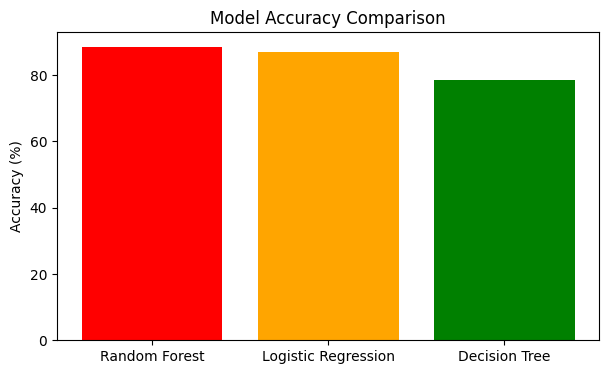

In [24]:
# Bar chart - Model Accuracy Comparison
plt.figure(figsize=(7, 4))
plt.bar(results['Model'], results['Accuracy'], color=['red', 'orange', 'green'])
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy (%)')
plt.show()

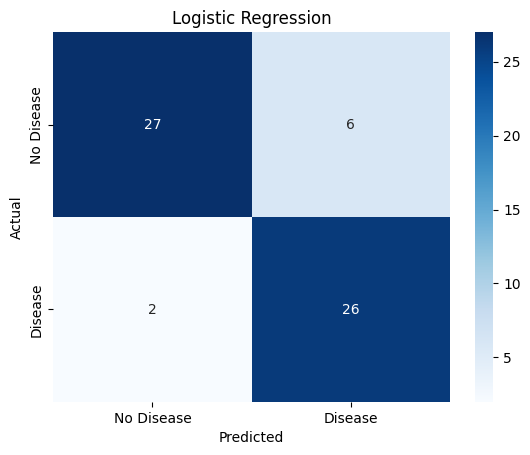

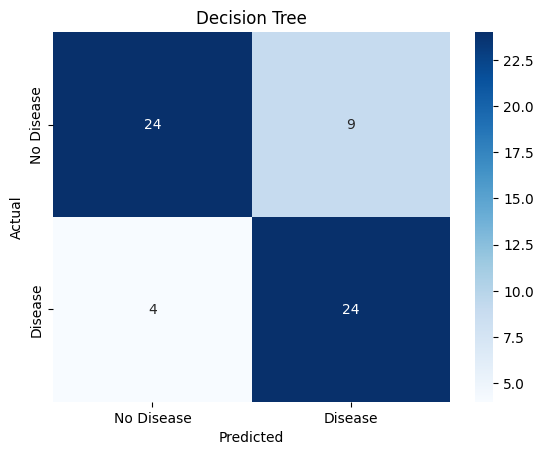

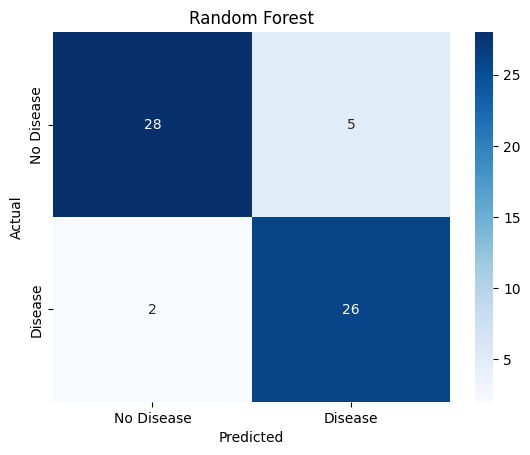

In [25]:
# Confusion Matrix - Logistic Regression
cm1 = confusion_matrix(y_test, lr_pred)
sns.heatmap(cm1, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Disease', 'Disease'],
            yticklabels=['No Disease', 'Disease'])
plt.title('Logistic Regression')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# Confusion Matrix - Decision Tree
cm2 = confusion_matrix(y_test, dt_pred)
sns.heatmap(cm2, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Disease', 'Disease'],
            yticklabels=['No Disease', 'Disease'])
plt.title('Decision Tree')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# Confusion Matrix - Random Forest
cm3 = confusion_matrix(y_test, rf_pred)
sns.heatmap(cm3, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Disease', 'Disease'],
            yticklabels=['No Disease', 'Disease'])
plt.title('Random Forest')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

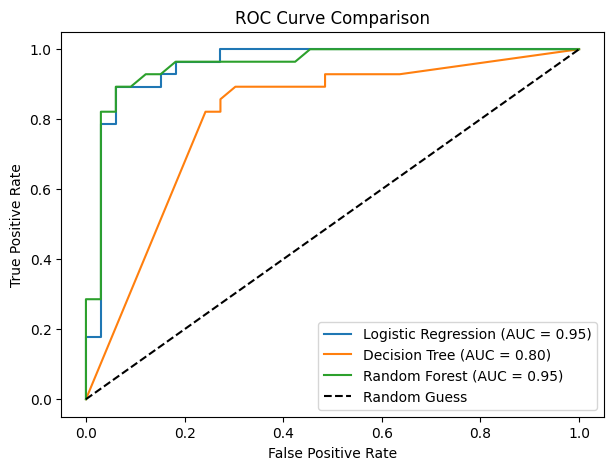

In [26]:
# ROC Curve for all 3 models
plt.figure(figsize=(7, 5))

# Logistic Regression
prob1 = lr_model.predict_proba(X_test_scaled)[:, 1]
fpr1, tpr1, _ = roc_curve(y_test, prob1)
plt.plot(fpr1, tpr1, label=f'Logistic Regression (AUC = {auc(fpr1, tpr1):.2f})')

# Decision Tree
prob2 = dt_model.predict_proba(X_test)[:, 1]
fpr2, tpr2, _ = roc_curve(y_test, prob2)
plt.plot(fpr2, tpr2, label=f'Decision Tree (AUC = {auc(fpr2, tpr2):.2f})')

# Random Forest
prob3 = rf_model.predict_proba(X_test)[:, 1]
fpr3, tpr3, _ = roc_curve(y_test, prob3)
plt.plot(fpr3, tpr3, label=f'Random Forest (AUC = {auc(fpr3, tpr3):.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.show()

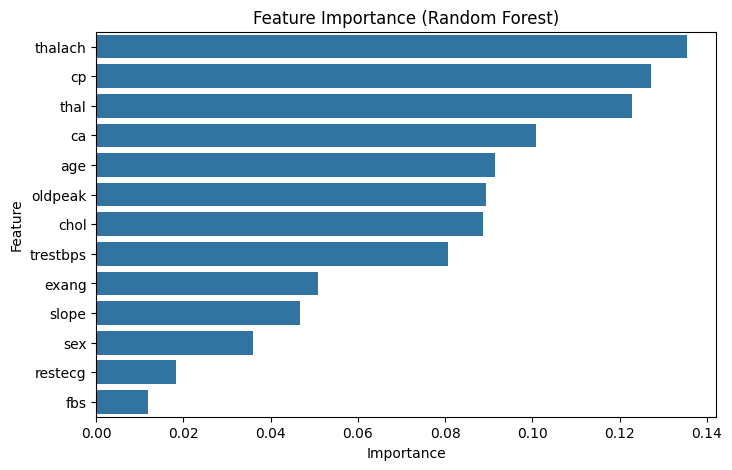

Top 5 most important features:
    Feature  Importance
7   thalach    0.135404
2        cp    0.127163
12     thal    0.122940
11       ca    0.100811
0       age    0.091327


In [27]:
# Feature Importance from Random Forest
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(data=feature_importance, x='Importance', y='Feature')
plt.title('Feature Importance (Random Forest)')
plt.show()

print('Top 5 most important features:')
print(feature_importance.head())

In [28]:
# Classification report - Random Forest
print(classification_report(y_test, rf_pred, target_names=['No Disease', 'Heart Disease']))

               precision    recall  f1-score   support

   No Disease       0.93      0.85      0.89        33
Heart Disease       0.84      0.93      0.88        28

     accuracy                           0.89        61
    macro avg       0.89      0.89      0.89        61
 weighted avg       0.89      0.89      0.89        61



## Step 10 - Save the Best Model

In [29]:
import pickle
import os

# Create model folder if not exists
os.makedirs('model', exist_ok=True)

# Save Random Forest model
with open('model/rf_model_heart_disease.pkl', 'wb') as f:
    pickle.dump(rf_model, f)

# Save scaler
with open('model/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print('Model saved successfully')

Model saved successfully


## Conclusion

Heart disease is one of the leading causes of death worldwide. 
Early prediction can save lives. In this project, we used real 
patient medical data to build a machine learning model that can 
predict whether a person has heart disease or not.

We explored the data and found some interesting patterns:

- Male patients are more likely to have heart disease than female patients
- Patients aged between 45 to 65 are at higher risk
- Maximum heart rate is a strong indicator - lower heart rate means higher risk
- Chest pain type and thalassemia are the most telling signs of heart disease
- Higher cholesterol and blood pressure are commonly seen in disease patients

We built and compared three machine learning models:

| Model | Accuracy |
|-------|----------|
| Logistic Regression | 86.89% |
| Decision Tree | 78.69% |
| Random Forest | 88.52% |

Random Forest performed the best with 88.52% accuracy. 
This means out of 100 patients, the model can correctly 
identify 88 whether they have heart disease or not.

The final model has been saved and deployed as a simple 
web application where anyone can enter their medical details 
and instantly know their heart disease risk 

This project shows how data science can be used in healthcare 
to assist doctors and save lives through early detection.